### Análisis y Procesamiento de Señales

# Trabajo Practico N1

### Pedro Joaquin Cannavo

## Introduccion

En este trabajo práctico se realizó la síntesis y análisis de diferentes señales en el dominio del tiempo y de la frecuencia, utilizando Python como herramienta para su generación, procesamiento y visualización.

A lo largo del trabajo se estudiaron señales sinusoidales, ruido aleatorio con distribución normal y uniforme, y una señal rectangular. Para cada caso se obtuvo la Transformada de Fourier mediante la FFT, analizando posteriormente el módulo de su espectro.

También se trabajó con el concepto de potencia media. Esto permitió determinar la amplitud necesaria para generar señales con una potencia determinada y relacionar la amplitud de una señal con la magnitud de su representación frecuencial.

Otro concepto importante trabajado fue la representación del espectro en decibeles. Para esto se utilizó como referencia una señal sinusoidal de *1W*, cuyo espectro se tomó como referencia de *0 dB*. De esta manera fue posible comparar las diferentes señales utilizando una misma escala.

Finalmente, se resolvió de manera analítica un segundo ejercicio relacionado con la convolución de señales discretas, utilizando una respuesta al impulso dada y diferentes señales de entrada.

## Desarrollo y analisis

### Ejercicio 1

Para comenzar con el desarrollo se establecieron los parámetros generales utilizados para todas las señales. Se trabajó con una cantidad de *N=1000* muestras y una frecuencia de muestreo de *fs=25000Hz*.

La frecuencia de las señales principales fue de *2000Hz*. Su período es:

$$ T_0=\frac{1}{f_0}=\frac{1}{2000}=0,5\,ms $$

Por lo tanto, para obtener al menos diez muestras por período se necesita una frecuencia de muestreo mínima de:

$$ f_s \geq 10f_0=20000\,Hz $$

Se utilizó *25000Hz*, por lo que se obtienen 12,5 muestras por período.

La generación de las señales sinusoidales se realizó mediante una función propia, que permite modificar parámetros como la amplitud, frecuencia, fase, componente continua, cantidad de muestras y frecuencia de muestreo. Esto permitió utilizar la misma función para generar las distintas señales solicitadas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

####################FUNCIONES##############################################

def funcion_seno(vmax, dc, ff, ph, nn, fs):
    
    tt = (np.arange(nn)/fs).reshape(-1, 1)
    
    xx = (vmax * np.sin(2 * np.pi * ff * tt + ph) + dc).reshape(-1, 1)
    
    return tt, xx

###########################################################################



#Para cada senal ver su modulo de la transformada
##################################################################################################
#Hago senal sinuoidal de 2000hz con muestreo de mas de 10 puntos por ciclo por ende minimo 20k

#Cantidad de muestras
N = 1000

#Frecuencia de muestreo 
fs = 25000

#Resistencia asumida
R = 1


Para poder expresar los resultados en decibeles se utilizó una señal sinusoidal de referencia cuya potencia media es de \(1\,W\).

Considerando una resistencia de *1 Ohm*, la tensión eficaz necesaria es:

$$ V_{rms}=\sqrt{P R}=1\,V $$

y, para una señal sinusoidal:

$$ V_{max}=V_{rms}\sqrt{2}=\sqrt{2}\,V $$

Se generó esta señal y se obtuvo su transformada de Fourier. El máximo del módulo de este espectro fue utilizado como referencia de *0 dB*.

In [2]:
#SEÑAL DE REFERENCIA PARA CALIBRAR EL ESPECTRO
##################################################################################################

#El profesor pide tomar una senoidal de 1 W como referencia de 0 dB

P_ref = 1

#Para R=1 ohm:
#P = Vrms^2 / R
Vrms_ref = np.sqrt(P_ref * R)

#Para una senoidal:
#Vrms = Vmax / sqrt(2)
vmax_ref = Vrms_ref * np.sqrt(2)

#Creo la senal de referencia de 1 W
tt_ref, xx_ref = funcion_seno(vmax=vmax_ref, dc=0, ff=2000, ph=0, nn=N, fs=fs)

#FFT de la senal de referencia
xx_ref_fft = np.fft.fft(xx_ref.flatten())

#Modulo del espectro de referencia
xx_ref_abs = np.abs(xx_ref_fft)

#Tomo el maximo del espectro como referencia para 0 dB
espectro_ref = np.max(xx_ref_abs)

print('Valor maximo del espectro de referencia:', espectro_ref)

##################################################################################################


Valor maximo del espectro de referencia: 707.1067811865469




Luego, para cada señal, su espectro fue dividido por el espectro de referencia y convertido a decibeles mediante:

$$ X_{dB}=20\log_{10}\left(\frac{|X(f)|}{|X_{ref}(f)|}\right) $$

De esta manera, una señal con el mismo nivel espectral que la referencia queda representada en *0 dB*.

También se utilizó *fftshift* para ordenar el espectro de forma que las frecuencias negativas y positivas queden centradas alrededor de *0 Hz*.

### Transformada de Fourier

Para analizar las señales en el dominio de la frecuencia se utilizó la Transformada Rápida de Fourier (FFT), implementada mediante *np.fft.fft()*.

La Transformada de Fourier permite pasar de una representación temporal de una señal a una representación en función de sus componentes frecuenciales. De esta manera, mientras que en el dominio temporal se observa cómo varía la señal con el tiempo, en el dominio de la frecuencia se puede analizar qué frecuencias están presentes.

La FFT devuelve valores complejos, por lo que para estudiar la magnitud de las componentes frecuenciales se calculó el módulo de la transformada:

$$ |X(f)| $$

Además, se construyó el eje de frecuencias correspondiente a los valores obtenidos mediante la FFT. En este caso, la resolución frecuencial es:

$$ \Delta f=\frac{f_s}{N} =\frac{25000}{1000} =25\,Hz $$

Por lo tanto, las componentes del espectro se encuentran separadas cada *25 Hz*.

Potencia media senal 1 = 0.499999999999999 W


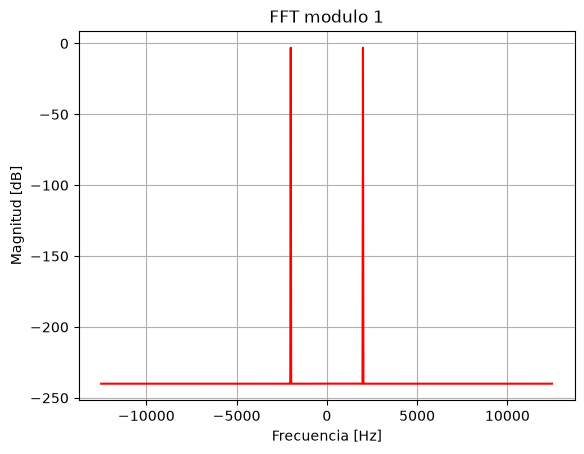

Amplitud segunda senal: 2.0000000000000004


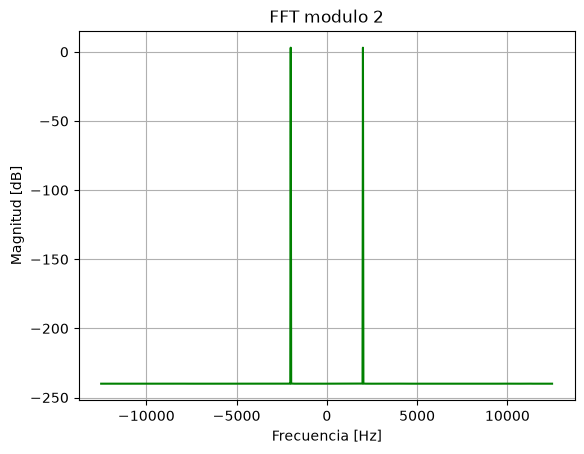

In [3]:
#PRIMER SINUSOIDAL
##################################################################################################

#Primer sinuoidal
tt1, xx1 = funcion_seno(vmax=1, dc=0, ff=2000, ph=0, nn=N, fs=fs)

#Potencia media de la primera senal
P1 = np.mean(xx1**2) / R
print('Potencia media senal 1 =', P1, 'W')

#FFT de la funcion para tenerlo representado en frecuencias
xx1_fft = np.fft.fft(xx1.flatten())

#Defino el eje en frecuencia para poder graficar
ff_eje = np.fft.fftfreq(N, 1/fs)

#Defino el modulo
xx1_abs = np.abs(xx1_fft)

#Normalizo usando el espectro de referencia
xx1_norm = xx1_abs / espectro_ref

#Paso a decibeles
xx1_db = 20 * np.log10(xx1_norm + 1e-12)

#Reordeno eje y espectro con fftshift para que quede continuo de -fs/2 a fs/2
ff_eje_shift = np.fft.fftshift(ff_eje)
xx1_db_shift = np.fft.fftshift(xx1_db)

#Grafico la funcion
plt.figure(1)
plt.plot(ff_eje_shift, xx1_db_shift, color='red')
plt.title('FFT modulo 1')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid(True)
plt.show()



##################################################################################################
#SEGUNDA SINUSOIDAL
##################################################################################################

#Aca hago la segunda senoidal que me piden que es con 2 W de potencia media
#y desfase de pi/2

#Calculo el dato de potencia media
Pmed = 2

Vrms = np.sqrt(Pmed * R)

vmax = Vrms * np.sqrt(2)

print('Amplitud segunda senal:', vmax)

#Creo la funcion
tt2, xx2 = funcion_seno(vmax, dc=0, ff=2000, ph=np.pi/2, nn=N, fs=fs)

#FFT de la funcion para tenerlo representado en frecuencias
xx2_fft = np.fft.fft(xx2.flatten())

#Defino el modulo
xx2_abs = np.abs(xx2_fft)

#Normalizo usando el espectro de referencia
xx2_norm = xx2_abs / espectro_ref

#Paso a decibeles
xx2_db = 20 * np.log10(xx2_norm + 1e-12)

#Reordeno eje y espectro con fftshift
xx2_db_shift = np.fft.fftshift(xx2_db)

#Grafico la funcion
plt.figure(2)
plt.plot(ff_eje_shift, xx2_db_shift, color='green')
plt.title('FFT modulo 2')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid(True)
plt.show()




### Ruido de distribución normal

A continuación se generó una secuencia de ruido aleatorio con distribución normal, valor medio de *0 V* y varianza de *0,1 W*.

En una distribución normal, la varianza está relacionada con el desvío estándar mediante:

$$ \sigma^2=\mathrm{Var}(x) $$

Por lo tanto:

$$ \sigma=\sqrt{0,1} $$

El ruido fue generado utilizando *np.random.normal()*, y posteriormente se sumó a la señal sinusoidal de referencia para analizar el efecto del ruido sobre su representación frecuencial.



In [4]:
###################################################################################################
#RUIDO NORMALMENTE DISTRIBUIDO
###################################################################################################

#Una secuencia aleatoria de ruido normalmente distribuido
#con DC (valor medio) 0V y varianza 0.1 W.

varianza1 = 0.1

sigma = np.sqrt(varianza1)

#Ahora que tengo esto puedo hacer mi ruido
#Creo ruido y luego armo mi funcion completa con ruido
ruido1 = np.random.normal(0, sigma, N).reshape(-1, 1)

xx1_ruidosa = xx1 + ruido1

#FFT de la funcion para tenerlo representado en frecuencias
xx1R_fft = np.fft.fft(xx1_ruidosa.flatten())

#Defino el modulo
xx1R_abs = np.abs(xx1R_fft)

#Normalizo usando el espectro de referencia
xx1R_norm = xx1R_abs / espectro_ref

#Paso a decibeles
xx1R_db = 20 * np.log10(xx1R_norm + 1e-12)

#Reordeno eje y espectro con fftshift
xx1R_db_shift = np.fft.fftshift(xx1R_db)



A diferencia de una señal sinusoidal, cuya energía se concentra principalmente en una frecuencia determinada, el ruido presenta componentes distribuidas en un rango amplio de frecuencias. Al sumarlo a la señal sinusoidal se mantiene la componente asociada a los *2000 Hz*, pero aparece un nivel adicional distribuido alrededor del espectro.

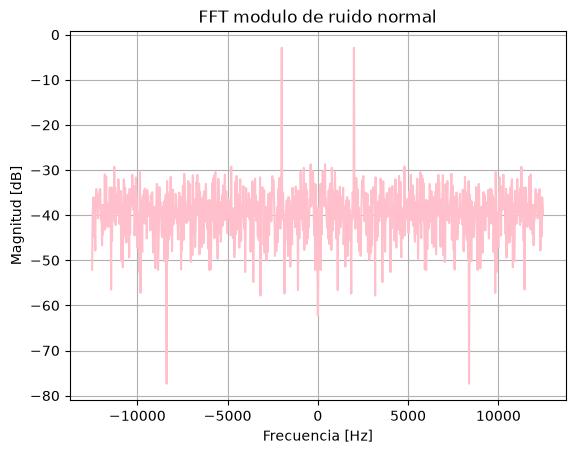

In [5]:
#Grafico la funcion
plt.figure(3)
plt.plot(ff_eje_shift, xx1R_db_shift, color='pink')
plt.title('FFT modulo de ruido normal')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid(True)
plt.show()

### Ruido de distribución uniforme

Luego se generó una segunda secuencia de ruido, pero utilizando una distribución uniforme. Al igual que en el caso anterior, se buscó obtener un valor medio de *0 V* y una varianza de *0,1 W*.

Para una distribución uniforme simétrica en el intervalo *[-a,a]*, la varianza está dada por:

$$ \sigma^2=\frac{a^2}{3} $$

Por lo tanto:

$$ a=\sqrt{3\sigma^2} $$

y utilizando una varianza de *0,1*:

$$ a=\sqrt{0,3} $$

De esta manera se obtuvo el intervalo utilizado para generar los valores aleatorios mediante *np.random.uniform()*.




In [6]:
###################################################################################################
#RUIDO UNIFORMEMENTE DISTRIBUIDO
###################################################################################################

#Una secuencia aleatoria de ruido uniformemente distribuido
#con DC (valor medio) 0V y varianza 0.1 W. 

#Con ruido uniforme es un toque distinto pq lo calculo distinto,
#tengo que poner un intervalo

varianza2 = 0.1

#Varianza para intervalos simetricos es igual a a al cuadrado sobre 3
#para este tipo de distribucion
#despejo para intervalo de [-a:a]
a = np.sqrt(0.1 * 3)

print('a es:', a)

#Creo ruido y luego armo mi funcion completa con ruido
ruido2 = np.random.uniform(-a, a, N).reshape(-1, 1)

xx2_ruidosa = xx1 + ruido2

#FFT de la funcion para tenerlo representado en frecuencias
xx2R_fft = np.fft.fft(xx2_ruidosa.flatten())

#Defino el modulo
xx2R_abs = np.abs(xx2R_fft)

#Normalizo usando el espectro de referencia
xx2R_norm = xx2R_abs / espectro_ref

#Paso a decibeles
xx2R_db = 20 * np.log10(xx2R_norm + 1e-12)

#Reordeno eje y espectro con fftshift
xx2R_db_shift = np.fft.fftshift(xx2R_db)


a es: 0.5477225575051662


Al igual que en el caso del ruido normal, el espectro presenta componentes distribuidas en diferentes frecuencias. Sin embargo, la forma en que se distribuyen las muestras en el dominio temporal es diferente debido a las características propias de cada distribución.



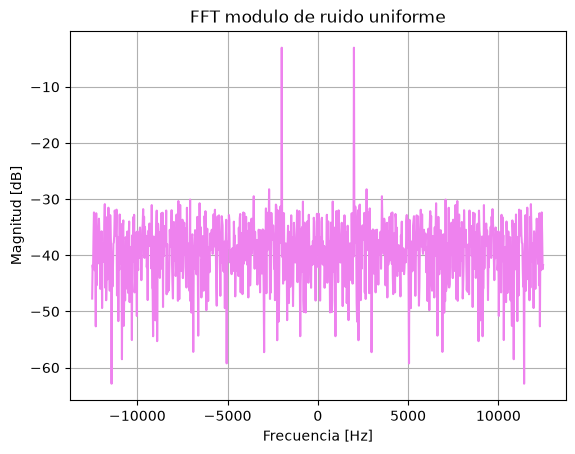

In [7]:
#Grafico la funcion
plt.figure(4)
plt.plot(ff_eje_shift, xx2R_db_shift, color='violet')
plt.title('FFT modulo de ruido uniforme')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid(True)
plt.show()


La comparación entre ambos tipos de ruido permitió observar que diferentes distribuciones estadísticas pueden producir señales con características temporales diferentes, aunque tengan el mismo valor medio y la misma varianza.

### Señal rectangular

Por último, se generó una señal rectangular de *2000 Hz*, con un ciclo de actividad del *50 %* y una potencia media de *1 W*.

Para generar esta señal se utilizó la función *signal.square()* de SciPy. Una señal rectangular con un ciclo de actividad del *50 %* permanece durante la mitad de cada período en un nivel positivo y durante la otra mitad en un nivel negativo.

En este caso, la señal toma valores de *+1V* y *-1V*. Al considerar *R=1 Omega*, ambos niveles generan una potencia instantánea de:

$$ P=\frac{V^2}{R}=1\,W $$

Por lo tanto, su potencia media también es de *1W*.

In [8]:
###################################################################################################
#PULSO RECTANGULAR
###################################################################################################

#Un pulso rectangular de la misma frecuencia, 1 W de potencia
#y ciclo de actividad del 50%.

ff = 2000

pulso = signal.square(2*np.pi*ff*tt1).reshape(-1, 1)

#Potencia instantanea es igual a Vmax al cuadrado,
#en este caso Vmax es uno y menos uno que cumplen
#Tambien se puede justificar que potencia media es Vrms al cuadrado
#y como es simetrica Vrms es igual a Vmax

pot = np.mean(pulso**2) / R

print('Potencia media pulso =', pot, 'W')

#FFT de la funcion para tenerlo representado en frecuencias
xx3_fft = np.fft.fft(pulso.flatten())

#Defino el modulo
xx3_abs = np.abs(xx3_fft)

#Normalizo usando el espectro de referencia
xx3_norm = xx3_abs / espectro_ref

#Paso a decibeles
xx3_db = 20 * np.log10(xx3_norm + 1e-12)

#Reordeno eje y espectro con fftshift
xx3_db_shift = np.fft.fftshift(xx3_db)


Potencia media pulso = 1.0 W


Al analizar su transformada de Fourier se observa una diferencia importante respecto de la señal sinusoidal. La señal rectangular no posee únicamente su frecuencia fundamental de *2000 Hz*, sino que también presenta componentes en frecuencias superiores correspondientes a sus armónicos.

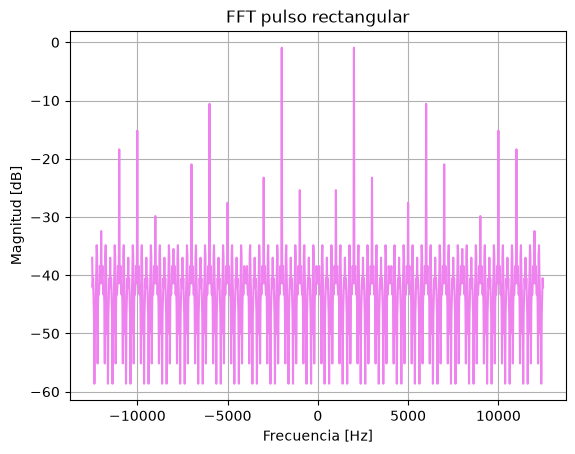

In [9]:
#Grafico la funcion
plt.figure(5)
plt.plot(ff_eje_shift, xx3_db_shift, color='violet') 
plt.title('FFT pulso rectangular')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid(True)
plt.show()

Esto permite relacionar la forma de una señal en el dominio temporal con la composición de su espectro: una señal con cambios bruscos, como la rectangular, requiere una mayor cantidad de componentes frecuenciales para representar su forma.

## Ejercicio 2

El segundo ejercicio fue realizado de forma analítica y su resolución completa se encuentra presentada en el PDF correspondiente.

En este caso se trabajó con la respuesta al impulso:

$$ h[n]=\delta[n]-\delta[n-4] $$

y se solicitó obtener la salida del sistema mediante la convolución:

$$ y[n]=x[n]*h[n] $$

Utilizando las propiedades de la convolución con impulsos desplazados, la expresión general puede simplificarse como:

$$ y[n]=x[n]-x[n-4] $$

A partir de esta expresión se resolvieron los tres casos propuestos, utilizando una señal sinusoidal, una señal exponencial y una señal definida mediante funciones escalón.

En particular, el ejercicio permitió relacionar el concepto de convolución con la respuesta al impulso de un sistema discreto y observar cómo una determinada respuesta *h[n]* modifica diferentes señales de entrada.

### Conclusión y autoevaluación del aprendizaje

Para concluir, este trabajo permitió profundizar el análisis de señales tanto en el dominio temporal como en el frecuencial. A través de la FFT se pudo observar cómo diferentes señales presentan distintas características en su espectro y cómo estas características se relacionan con su forma de onda.

En el caso de las señales sinusoidales se verificó que su espectro se encuentra concentrado principalmente en su frecuencia fundamental. También se pudo comprobar que modificar la fase de una señal no altera el módulo de su transformada, mientras que modificar su amplitud sí produce un cambio en la magnitud espectral.

El análisis de potencia permitió relacionar la amplitud de las señales con la energía que entregan a una resistencia. En particular, se comprobó que la primera señal posee *0,5 W*, mientras que la segunda posee *2 W*, siendo esta última cuatro veces mayor en potencia.

La utilización de una señal de *1 W* como referencia permitió además expresar los espectros en decibeles y comparar las diferentes señales utilizando una escala común. Esto permitió comprender mejor la relación entre potencia, amplitud y representación espectral.

Por otro lado, el análisis de los ruidos normal y uniforme permitió observar que una señal aleatoria presenta componentes distribuidas en un rango amplio de frecuencias, a diferencia de una señal sinusoidal. Finalmente, la señal rectangular permitió observar la aparición de armónicos como consecuencia de su forma de onda y de sus cambios abruptos.

El segundo ejercicio permitió complementar el análisis computacional con una resolución analítica, trabajando con convolución, respuesta al impulso y señales discretas. De esta manera, el trabajo permitió relacionar conceptos teóricos vistos en clase con resultados obtenidos mediante programación.

En lo personal, este trabajo me permitió continuar familiarizándome con Python y, principalmente, con las herramientas de NumPy, SciPy y Matplotlib aplicadas al procesamiento de señales. También me ayudó a comprender mejor la representación frecuencial mediante FFT, la interpretación de los espectros y la utilización de los decibeles como forma de comparación entre señales.